In [61]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="images/group.png", width=700, height=400)

## Why Grouping and Aggregation Matter in Data Science

Grouping and aggregation are foundational techniques in data analysis that transform raw data into actionable insights. Here's why they're essential:

**Data Summarization**  
Grouping allows you to condense large amounts of data into concise summaries. Aggregation provides statistical summaries (e.g., mean, sum, count), making it easier to understand data trends and characteristics without needing to examine every detail.

**Insights Across Categories**  
Grouping by categories—like regions, demographics, or time periods—lets you analyze patterns within each group. For example:

- Aggregating sales data by region can reveal which areas are performing better.
- Grouping customer data by age group can highlight consumer trends.
- Comparing product performance across different market segments.

**Time Series Analysis**  
In time-series data, grouping by time intervals (e.g., day, month, quarter) allows you to observe trends over time, which is crucial for forecasting, seasonal analysis, and trend detection.

**Reducing Data Complexity**  
By summarizing data at a higher level, you reduce complexity, making it easier to visualize and interpret—especially in large datasets where working with raw data could be overwhelming.



In this chapter, we'll explore grouping and aggregating using pandas. These methods will help you group and summarize data, making complex analysis comparatively easy.

Throughout this chapter, we'll use the **GDP and Life Expectancy dataset** (`gdp_lifeExpectancy.csv`), which contains information about countries' GDP per capita and life expectancy over time. This dataset is ideal for demonstrating how grouping can reveal patterns across countries, continents, and years.

Let's start by importing the necessary libraries and loading the data.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set visualization defaults
sns.set(font_scale=1.5)
%matplotlib inline

In [2]:
# Load the GDP and Life Expectancy dataset
gdp_lifeExp_data = pd.read_csv('./Datasets/gdp_lifeExpectancy.csv')

# Display the first few rows to understand the structure
gdp_lifeExp_data.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


## Categorical Aggregation

Before diving into advanced grouping operations, it's important to understand how to aggregate **categorical variables**. Unlike numerical aggregation (mean, sum, etc.), categorical aggregation focuses on **counting frequencies** and understanding the distribution of categories.

Categorical aggregation helps answer questions like:

- How many observations belong to each category?
- What's the distribution across different categories?
- How do two categorical variables relate to each other?

### One-way Aggregation: `value_counts()`

The [`value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) method is the simplest way to count occurrences of each unique value in a categorical column. It returns a Series with categories as the index and their counts as values.

**Example:** Let's count how many observations (country-year combinations) we have for each continent.

In [3]:
# Count the number of observations for each continent
continent_counts = gdp_lifeExp_data['continent'].value_counts()
continent_counts

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64

**Interpretation:** Africa has the most observations (624), while Oceania has the fewest (24). This tells us the dataset has unequal representation across continents.

#### Useful `value_counts()` Parameters

The `value_counts()` method has several useful parameters:

- **`normalize=True`** - Returns proportions instead of counts
- **`sort=False`** - Returns results in the order they appear (not sorted by frequency)
- **`dropna=False`** - Includes counts of missing values

Let's see the **proportion** of observations in each continent:

In [4]:
# Get proportions instead of counts
continent_proportions = gdp_lifeExp_data['continent'].value_counts(normalize=True)
print("Proportions of observations by continent:")
print(continent_proportions)
print(f"\nAfrica represents {continent_proportions['Africa']:.1%} of all observations")

Proportions of observations by continent:
continent
Africa      0.366197
Asia        0.232394
Europe      0.211268
Americas    0.176056
Oceania     0.014085
Name: proportion, dtype: float64

Africa represents 36.6% of all observations


### Two-way Aggregation: `crosstab()`

While `value_counts()` works for a single categorical variable, [`crosstab()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html) is used to examine the relationship between **two categorical variables**. It creates a frequency table (also called a contingency table) showing counts for each combination of categories.

**Use case:** `crosstab()` is ideal for:

- Understanding how categories from two variables overlap
- Checking data balance across multiple dimensions
- Creating frequency tables for statistical analysis

The `crosstab()` method is a special case of a pivot table specifically designed for computing group frequencies (or the size of each group).

#### Basic `crosstab()` Example

Let's start with a simple one-way frequency count using `crosstab()`. While `value_counts()` is more direct for this purpose, `crosstab()` can do it too:

In [5]:
# Create a basic crosstab to count observations by continent
# The 'columns' parameter is just a label for the column header
pd.crosstab(gdp_lifeExp_data['continent'], columns='count')

col_0,count
continent,
Africa,624
Americas,300
Asia,396
Europe,360
Oceania,24


#### Two-way Frequency Table

Now let's create a **two-way frequency table** to see how observations are distributed across both `continent` and `year`. This helps us understand the temporal coverage for each continent.

**Adding Margins:**  
Use the `margins=True` argument to add row and column totals. The `All` row and column provide the sum across each dimension.

In [6]:
# Create a two-way frequency table for continent and year
continent_year_table = pd.crosstab(
    gdp_lifeExp_data['continent'], 
    gdp_lifeExp_data['year'], 
    margins=True
)

# Display the table
continent_year_table

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007,All
continent,,,,,,,,,,,,,
Africa,52,52,52,52,52,52,52,52,52,52,52,52,624
Americas,25,25,25,25,25,25,25,25,25,25,25,25,300
Asia,33,33,33,33,33,33,33,33,33,33,33,33,396
Europe,30,30,30,30,30,30,30,30,30,30,30,30,360
Oceania,2,2,2,2,2,2,2,2,2,2,2,2,24
All,142,142,142,142,142,142,142,142,142,142,142,142,1704


**Interpretation:**

- Each cell shows the count of country-year observations for that continent-year combination
- The `All` column shows total observations per continent (same as `value_counts()`)
- The `All` row shows total observations per year
- The bottom-right cell (1704) is the grand total of all observations

This table is useful for:

- Checking if data is representative across all groups
- Identifying any missing years for specific continents
- Understanding the temporal balance of your dataset

#### Using `crosstab()` with Aggregation Functions

So far, we've used `crosstab()` to count frequencies. However, you can also use it to **aggregate numerical values** for each category combination by specifying:

- **`values`** - The numerical column to aggregate
- **`aggfunc`** - The aggregation function to apply (e.g., 'mean', 'sum', 'median')

This makes `crosstab()` a powerful tool that combines categorical grouping with numerical aggregation.

**Example:** Calculate the mean life expectancy for each continent-year combination.

This helps us see how life expectancy has evolved over time across different continents.

In [7]:
# Calculate mean life expectancy for each continent-year combination
mean_lifeExp_table = pd.crosstab(
    gdp_lifeExp_data['continent'], 
    gdp_lifeExp_data['year'], 
    values=gdp_lifeExp_data['lifeExp'], 
    aggfunc='mean'
)

# Round to 1 decimal place for better readability
mean_lifeExp_table = mean_lifeExp_table.round(1)

# Display the table
mean_lifeExp_table

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7


**Key Insights:**

- Life expectancy has generally increased over time across all continents
- Oceania consistently has the highest life expectancy
- Africa has the lowest life expectancy, though it's improving
- The gap between continents is gradually narrowing over time


While `crosstab()` is excellent for two-way categorical analysis, `groupby()` offers significantly more flexibility:

Think of it as a progression:

- **`value_counts()`** → Count frequencies for one variable
- **`crosstab()`** → Cross-tabulate two categorical variables with optional aggregation
- **`groupby()`** → The most flexible and powerful grouping tool for all scenarios

In the next section, we'll explore `groupby()` in depth, starting with single-column grouping and gradually building up to more complex operations.

## `groupby()`: Grouping by a Single Column

The `groupby()` method allows you to split a DataFrame based on the values in one or more columns, creating groups that can be analyzed separately. Unlike `crosstab()`, which is optimized for creating cross-tabulation tables, `groupby()` gives you complete control over how to aggregate, transform, and filter your data.

### Syntax of `groupby()`

```python
DataFrame.groupby(by="column_name")
```

This creates a **GroupBy object** that represents the grouped data. 

### Example: Grouping by Continent

Let's group the life expectancy data by `continent`. This will allow us to analyze statistics separately for each continent.

In [8]:
# Create a GroupBy object by grouping data by 'continent'
grouped = gdp_lifeExp_data.groupby('continent')

# This logically splits the data into groups based on unique values of 'continent'
# However, the data is not physically split into separate DataFrames
grouped

### Understanding the GroupBy Object

The `groupby()` method returns a **GroupBy object**, not a DataFrame. This object contains information about how the data is grouped, but doesn't display the groups directly.

In [9]:
# Check the type of the grouped object
type(grouped)

pandas.core.groupby.generic.DataFrameGroupBy

**Key Point:** The GroupBy object `grouped` contains the information about how observations are distributed across groups. Each observation has been assigned to a specific group based on the value of `continent` for that observation. However, the dataset is **not physically split** into different DataFrames—all observations remain in the same DataFrame `gdp_lifeExp_data`until you apply an aggregation or transformation.


### Exploring GroupBy Objects: Attributes and Methods

The [GroupBy object](https://pandas.pydata.org/docs/reference/groupby.html) has several useful attributes and methods that help you understand and work with your grouped data. Let's explore the most important ones.

#### `keys` - Identifying the Grouping Column(s)

The column(s) used to group the data are called **keys**. You can view the grouping key(s) using the `keys` attribute.

In [10]:
# View the grouping key(s)
grouped.keys

'continent'

####  `ngroups` - Counting the Number of Groups

The [`ngroups`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.ngroups.html) attribute tells you how many unique groups exist based on the grouping key(s).

In [11]:
# Count the number of groups
grouped.ngroups

5

#### `groups` - Viewing Group Names and Their Members

The [`groups`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.groups.html) attribute returns a dictionary where:

- **Keys** are the group names (unique values of the grouping column)
- **Values** are the row indices (labels) of observations belonging to each group

In [12]:
# View the group names (keys of the dictionary)
grouped.groups.keys()

dict_keys(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'])

In [13]:
# View the complete groups dictionary (group names and their row indices)
grouped.groups

{'Africa': [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, ...], 'Americas': [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 432, 433, 434, 435, ...],

You can also access just the row indices (values) for all groups:

In [14]:
# View the row indices for all groups
grouped.groups.values()

dict_values([Index([  24,   25,   26,   27,   28,   29,   30,   31,   32,   33,
       ...
       1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703],
      dtype='int64', length=624), Index([  48,   49,   50,   51,   52,   53,   54,   55,   56,   57,
       ...
       1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643],
      dtype='int64', length=300), Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679],
      dtype='int64', length=396), Index([  12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
       ...
       1598, 1599, 1600, 1601, 1602, 1603, 1604, 1605, 1606, 1607],
      dtype='int64', length=360), Index([  60,   61,   62,   63,   64,   65,   66,   67,   68,   69,   70,   71,
       1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103],
      dtype='int64')])

#### `size()` - Counting Observations per Group

The [`size()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.size.html) method returns the number of observations in each group. This is useful for understanding the distribution of data across groups.

In [15]:
# Count the number of observations in each continent group
grouped.size()

continent
Africa      624
Americas    300
Asia        396
Europe      360
Oceania      24
dtype: int64

#### `first()` - Viewing the First Element of Each Group

The [`first()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.first.html) method returns the first non-missing element from each group. This can be useful for quickly inspecting what each group looks like.

In [16]:
# View the first non-missing observation from each continent group
grouped.first()

,country,year,lifeExp,pop,gdpPercap
continent,,,,,
Africa,Algeria,1952,43.077,9279525,2449.008185
Americas,Argentina,1952,62.485,17876956,5911.315053
Asia,Afghanistan,1952,28.801,8425333,779.445314
Europe,Albania,1952,55.230,1282697,1601.056136
Oceania,Australia,1952,69.120,8691212,10039.595640


#### `get_group()` - Extracting Data for a Specific Group

The [`get_group()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.get_group.html) method returns all observations belonging to a particular group. This is useful when you want to analyze or visualize a specific group in detail.

In [17]:
# Extract all observations for the 'Asia' continent
grouped.get_group('Asia').head(10)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
5,Afghanistan,Asia,1977,38.438,14880372,786.113360
6,Afghanistan,Asia,1982,39.854,12881816,978.011439
7,Afghanistan,Asia,1987,40.822,13867957,852.395945
8,Afghanistan,Asia,1992,41.674,16317921,649.341395
9,Afghanistan,Asia,1997,41.763,22227415,635.341351


## Data Aggregation Within Groups

Once you've created a GroupBy object, the real power comes from applying **aggregation functions** to summarize the data within each group. Aggregation functions compute summary statistics that help you understand patterns and trends across different groups.

### Common Aggregation Functions

Below are the most commonly used aggregation functions when working with grouped data in pandas:

| Function | Description | Example Use Case |
|----------|-------------|------------------|
| `mean()` | Calculates the **average** value | Average life expectancy per continent |
| `sum()` | Computes the **total** by summing all values | Total population across countries |
| `min()` | Finds the **minimum** value | Lowest GDP per capita in each region |
| `max()` | Finds the **maximum** value | Highest life expectancy in each year |
| `count()` | Counts the **number of non-null entries** | Number of countries per continent |
| `median()` | Finds the **middle value** when sorted | Median income across categories |
| `std()` | Calculates the **standard deviation** | Variability in GDP within continents |

Each of these functions helps summarize different aspects of your grouped data, making it easier to identify trends, outliers, and patterns.

### Example: Calculating Mean Statistics by Country

Let's find the mean life expectancy, population, and GDP per capita for each country during the period 1952-2007. This will give us a single summary statistic for each country across all years in the dataset.

**Approach:**

1. Remove columns we don't want to aggregate (`continent` and `year`)
2. Group by `country`
3. Calculate the mean for all remaining numeric columns

In [18]:
# Group the data by 'country' and calculate mean statistics
# First, drop columns we don't want to aggregate
grouped_country = gdp_lifeExp_data.drop(['continent', 'year'], axis=1).groupby('country')

# Calculate the mean for all numeric columns (lifeExp, pop, gdpPercap)
country_means = grouped_country.mean()

# Display the results
country_means.head(10)

,lifeExp,pop,gdpPercap
country,,,
Afghanistan,37.478833,1.582372e+07,802.674598
Albania,68.432917,2.580249e+06,3255.366633
Algeria,59.030167,1.987541e+07,4426.025973
Angola,37.883500,7.309390e+06,3607.100529
Argentina,69.060417,2.860224e+07,8955.553783
Australia,74.662917,1.464931e+07,19980.595634
Austria,73.103250,7.583298e+06,20411.916279
Bahrain,65.605667,3.739132e+05,18077.663945
Bangladesh,49.834083,9.075540e+07,817.558818


### Calculating Other Statistics

We can apply different aggregation functions to understand the variability and spread of data within each group. Let's calculate the standard deviation to see how much variation exists within each country over time.

In [19]:
# Calculate the standard deviation for each country
country_std = grouped_country.std()

# Display the results
country_std.head(10)

,lifeExp,pop,gdpPercap
country,,,
Afghanistan,5.098646,7.114583e+06,108.202929
Albania,6.322911,8.285855e+05,1192.351513
Algeria,10.340069,8.613355e+06,1310.337656
Angola,4.005276,2.672281e+06,1165.900251
Argentina,4.186470,7.546609e+06,1862.583151
Australia,4.147774,3.915203e+06,7815.405220
Austria,4.379838,4.376600e+05,9655.281488
Bahrain,8.571871,2.108933e+05,5415.413364
Bangladesh,9.028335,3.471166e+07,235.079648


**Interpretation:** Countries with higher standard deviations in `lifeExp` experienced greater changes in life expectancy over the years, while those with lower standard deviations remained more stable.

You can apply any of the aggregation functions mentioned earlier (`min()`, `max()`, `count()`, `median()`, etc.) in the same way to compute different statistics for your groups.

## Multiple and Custom Aggregations Using `agg()`

While applying single aggregation functions like `mean()` or `std()` is useful, you'll often need to:

1. Apply **multiple aggregation functions** simultaneously
2. Use **custom aggregation functions** that aren't built into pandas

The [`agg()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html) method of a GroupBy object provides this flexibility.

### Multiple Aggregations on a Single Column

When you need to compute several statistics for the same column, pass a **list of function names** to `agg()`.

**Example:** Calculate both the mean and standard deviation of GDP per capita for each country.

In [20]:
# Apply multiple aggregation functions to 'gdpPercap' column
gdp_stats = grouped_country['gdpPercap'].agg(['mean', 'std'])

# Sort by mean GDP per capita (descending) and show top 10
gdp_stats.sort_values(by='mean', ascending=False).head(10)

,mean,std
country,,
Kuwait,65332.910472,33882.139536
Switzerland,27074.334405,6886.463308
Norway,26747.306554,13421.947245
United States,26261.151347,9695.058103
Canada,22410.746340,8210.112789
Netherlands,21748.852208,8918.866411
Denmark,21671.824888,8305.077866
Germany,20556.684433,8076.261913
Iceland,20531.422272,9373.245893


### Custom Aggregation Functions

In addition to built-in functions, you can create your own custom aggregation functions. This is useful when you need a statistic that isn't available in pandas.

**Example:** Calculate the **range** (max - min) of GDP per capita for each country using a lambda function.

In [21]:
# Calculate the range (max - min) of gdpPercap for each country using a lambda function
gdp_range = grouped_country['gdpPercap'].agg(lambda x: x.max() - x.min())

# Display the results sorted by range (descending)
gdp_range.sort_values(ascending=False).head(10)

country
Kuwait              85404.702920
Singapore           44828.041413
Norway              39261.768450
Hong Kong, China    36670.557461
Ireland             35465.716022
Austria             29989.416208
United States       28961.171010
Iceland             28913.100762
Japan               28439.111713
Netherlands         27856.361462
Name: gdpPercap, dtype: float64

In [22]:
# Alternatively, define a named function for better readability
def range_func(x):
    """Calculate the range (max - min) of a series"""
    return x.max() - x.min()

In [23]:
# Combine built-in functions with custom functions
gdp_complete_stats = grouped_country['gdpPercap'].agg(['mean', 'std', range_func])

# Sort by range and display top 10 countries
gdp_complete_stats.sort_values(by='range_func', ascending=False).head(10)

,mean,std,range_func
country,,,
Kuwait,65332.910472,33882.139536,85404.702920
Singapore,17425.382267,14926.147774,44828.041413
Norway,26747.306554,13421.947245,39261.768450
"Hong Kong, China",16228.700865,12207.329731,36670.557461
Ireland,15758.606238,11573.311022,35465.716022
Austria,20411.916279,9655.281488,29989.416208
United States,26261.151347,9695.058103,28961.171010
Iceland,20531.422272,9373.245893,28913.100762
Japan,17750.869984,10131.612545,28439.111713


### Renaming Aggregated Columns

For better readability and professional reporting, you can rename the columns resulting from aggregation. Pass a **list of tuples** to `agg()`, where each tuple contains:

1. The new column name (string)
2. The aggregation function (string or callable)

**Example:** Create a summary table with custom column names and include a 90th percentile calculation.

In [24]:
# Apply multiple aggregations with custom column names
gdp_summary = grouped_country['gdpPercap'].agg(
    [('Average', 'mean'),
     ('Standard Deviation', 'std'),
    ('90th Percentile', lambda x: x.quantile(0.9))
    ])

# Sort by 90th percentile and display top 10
gdp_summary.sort_values(by='90th Percentile', ascending=False).head(10)

,Average,Standard Deviation,90th Percentile
country,,,
Kuwait,65332.910472,33882.139536,109251.315590
Norway,26747.306554,13421.947245,44343.894158
United States,26261.151347,9695.058103,38764.132898
Singapore,17425.382267,14926.147774,35772.742520
Switzerland,27074.334405,6886.463308,34246.394240
Netherlands,21748.852208,8918.866411,33376.895065
Ireland,15758.606238,11573.311022,33121.539164
Canada,22410.746340,8210.112789,32891.561152
Saudi Arabia,20261.743635,8754.387440,32808.019502


## Multiple Aggregations on Multiple Columns

Often, you'll want to apply the same aggregation functions to several columns simultaneously. This is straightforward with `agg()`.

**Example:** Calculate the mean and standard deviation of both life expectancy (`lifeExp`) and population (`pop`) for each country.

In [25]:
# Apply the same aggregations to multiple columns
multi_column_stats = grouped_country[['lifeExp', 'pop']].agg(['mean', 'std'])

# Sort by mean life expectancy (descending)
multi_column_stats.sort_values(by=('lifeExp', 'mean'), ascending=False).head(10)

lifeExp                     pop              
                  mean       std          mean           std
country                                                     
Iceland      76.511417  3.026593  2.269781e+05  4.854168e+04
Sweden       76.177000  3.003990  8.220029e+06  6.365660e+05
Norway       75.843000  2.423994  4.031441e+06  4.107955e+05
Netherlands  75.648500  2.486363  1.378680e+07  2.005631e+06
Switzerland  75.565083  4.011572  6.384293e+06  8.582009e+05
Canada       74.902750  3.952871  2.446297e+07  5.940793e+06
Japan        74.826917  6.494629  1.117588e+08  1.488988e+07
Australia    74.662917  4.147774  1.464931e+07  3.915203e+06
Denmark      74.370167  2.220111  4.994187e+06  3.520599e+05
France       74.348917  4.304761  5.295256e+07  6.086809e+06

## Different Aggregations for Different Columns

Sometimes you need to apply **different sets of functions to different columns**. For this, pass a **dictionary** to `agg()` where:

- **Keys** are column names
- **Values** are lists of aggregation functions (as strings or callables)

This approach gives you complete control over which statistics are computed for each column.

In [26]:
# Apply different aggregation functions to different columns using a dictionary
varied_stats = grouped_country.agg({
    'gdpPercap': ['mean', 'std'],      # Mean and std for GDP per capita
    'lifeExp': ['median', 'std'],      # Median and std for life expectancy
    'pop': ['max', 'min']              # Max and min for population
})

# Display the first 10 rows
varied_stats.head(10)

gdpPercap               lifeExp                   pop  \
                     mean          std   median        std        max   
country                                                                 
Afghanistan    802.674598   108.202929  39.1460   5.098646   31889923   
Albania       3255.366633  1192.351513  69.6750   6.322911    3600523   
Algeria       4426.025973  1310.337656  59.6910  10.340069   33333216   
Angola        3607.100529  1165.900251  39.6945   4.005276   12420476   
Argentina     8955.553783  1862.583151  69.2115   4.186470   40301927   
Australia    19980.595634  7815.405220  74.1150   4.147774   20434176   
Austria      20411.916279  9655.281488  72.6750   4.379838    8199783   
Bahrain      18077.663945  5415.413364  67.3225   8.571871     708573   
Bangladesh     817.558818   235.079648  48.4660   9.028335  150448339   
Belgium      19900.758072  8391.186269  73.3650   3.779658   10392226   

                       
                  min  
country                
Afghanistan   8425333  
Albania       1282697  
Algeria       9279525  
Angola        4232095  
Argentina    17876956  
Australia     8691212  
Austria       6927772  
Bahrain        120447  
Bangladesh   46886859  
Belgium       8730405

### Combining Dictionary Syntax with Custom Column Names

You can also use the dictionary approach with custom column names by passing tuples as the aggregation values.

**Example:** For each country, calculate:

- Mean and standard deviation of life expectancy (with custom names)
- Min and max values of GDP per capita

In [27]:
# Apply different functions to different columns with custom names
custom_varied_stats = grouped_country.agg({
    'lifeExp': [('Average', 'mean'), 
    ('Standard deviation', 'std')],
    'gdpPercap': ['min', 'max']
})

# Display the first 10 rows
custom_varied_stats.head(10)

lifeExp                        gdpPercap              
               Average Standard deviation           min           max
country                                                              
Afghanistan  37.478833           5.098646    635.341351    978.011439
Albania      68.432917           6.322911   1601.056136   5937.029526
Algeria      59.030167          10.340069   2449.008185   6223.367465
Angola       37.883500           4.005276   2277.140884   5522.776375
Argentina    69.060417           4.186470   5911.315053  12779.379640
Australia    74.662917           4.147774  10039.595640  34435.367440
Austria      73.103250           4.379838   6137.076492  36126.492700
Bahrain      65.605667           8.571871   9867.084765  29796.048340
Bangladesh   49.834083           9.028335    630.233627   1391.253792
Belgium      73.641750           3.779658   8343.105127  33692.605080

## Grouping by Multiple Columns

Above, we demonstrated grouping by a single column, which is useful for summarizing data based on one categorical variable. However, in many cases, we need to group by multiple columns. Grouping by multiple columns allows us to create more detailed summaries by accounting for multiple categorical variables. This approach enables us to analyze data at a finer granularity, revealing insights that might be missed with single-column grouping alone. 

### Basic Syntax for Grouping by Multiple Columns

Use `groupby()` with a list of column names to group data by multiple columns.

* `DataFrame.groupby(by=["col1", "col2"])` 

Consider the life expectancy dataset, we can group by both country and continent to analyze `gdpPercap`, `lifeExp`, and `pop` trends for each country within each continent, providing a more comprehensive view of the data.

In [28]:
#Grouping by multiple columns
grouped_continent_contry = gdp_lifeExp_data.groupby(['continent', 'country'])[ "lifeExp"].agg(['mean', 'std', 'max', 'min']).sort_values(by = 'mean', ascending = False)

In [29]:
grouped_continent_contry

mean       std     max     min
continent country                                           
Europe    Iceland        76.511417  3.026593  81.757  72.490
          Sweden         76.177000  3.003990  80.884  71.860
          Norway         75.843000  2.423994  80.196  72.670
          Netherlands    75.648500  2.486363  79.762  72.130
          Switzerland    75.565083  4.011572  81.701  69.620
...                            ...       ...     ...     ...
Africa    Mozambique     40.379500  4.599184  46.344  31.286
          Guinea-Bissau  39.210250  4.937369  46.388  32.500
          Angola         37.883500  4.005276  42.731  30.015
Asia      Afghanistan    37.478833  5.098646  43.828  28.801
Africa    Sierra Leone   36.769167  3.937828  42.568  30.331

[142 rows x 4 columns]

### Understanding Hierarchical (Multi-Level) Indexing

* Grouping by multiple columns creates a hierarchical index (also called a multi-level index).
* This index allows each level (e.g., continent, country) to act as an independent category that can be accessed individually.

 In the above output, `continent` and `country` form a two-level hierarchical index, allowing us to drill down from continent-level to country-level summaries.

In [30]:
grouped_continent_contry.index.nlevels

2

In [31]:
# get the first level of the index
grouped_continent_contry.index.levels[0]

Index(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'], dtype='object', name='continent')

In [32]:
# get the second level of the index
grouped_continent_contry.index.levels[1]

Index(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Australia',
       'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       ...
       'Uganda', 'United Kingdom', 'United States', 'Uruguay', 'Venezuela',
       'Vietnam', 'West Bank and Gaza', 'Yemen, Rep.', 'Zambia', 'Zimbabwe'],
      dtype='object', name='country', length=142)

### Subsetting Data in a Hierarchical Index

`grouped_continent_country` is still a DataFrame with hierarchical indexing. You can use `.loc[]` for subsetting, just as you would with a single-level index.

In [33]:
# get the observations for the 'Americas' continent
grouped_continent_contry.loc['Americas'].head()

,mean,std,max,min
country,,,,
Canada,74.902750,3.952871,80.653,68.750
United States,73.478500,3.343781,78.242,68.440
Puerto Rico,72.739333,3.984267,78.746,64.280
Cuba,71.045083,6.022798,78.273,59.421
Uruguay,70.781583,3.342937,76.384,66.071


In [34]:
# get the mean life expectancy for the 'Americas' continent
grouped_continent_contry.loc['Americas']['mean'].head()

country
Canada           74.902750
United States    73.478500
Puerto Rico      72.739333
Cuba             71.045083
Uruguay          70.781583
Name: mean, dtype: float64

In [35]:
# another way to get the mean life expectancy for the 'Americas' continent
grouped_continent_contry.loc['Americas', 'mean'].head()

country
Canada           74.902750
United States    73.478500
Puerto Rico      72.739333
Cuba             71.045083
Uruguay          70.781583
Name: mean, dtype: float64

You can use a tuple to access data for specific levels in a multi-level index.

In [36]:
# get the observations for the 'United States' country
grouped_continent_contry.loc[( 'Americas', 'United States')]

mean    73.478500
std      3.343781
max     78.242000
min     68.440000
Name: (Americas, United States), dtype: float64

In [37]:
grouped_continent_contry.loc[( 'Americas', 'United States'), ['mean', 'std']]

mean    73.478500
std      3.343781
Name: (Americas, United States), dtype: float64

In [38]:
gdp_lifeExp_data.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')

Finally, you can use `reset_index()` to convert the hierarchical index into a regular index, allowing you to apply the standard subsetting and filtering methods covered in previous chapters

In [39]:
grouped_continent_contry.reset_index().head()

,continent,country,mean,std,max,min
0,Europe,Iceland,76.511417,3.026593,81.757,72.49
1,Europe,Sweden,76.177000,3.003990,80.884,71.86
2,Europe,Norway,75.843000,2.423994,80.196,72.67
3,Europe,Netherlands,75.648500,2.486363,79.762,72.13
4,Europe,Switzerland,75.565083,4.011572,81.701,69.62


### Grouping by multiple columns and aggregating multiple variables

In [40]:
#Grouping by multiple columns
grouped_continent_contry_multi = gdp_lifeExp_data.groupby(['continent', 'country','year'])[ ['lifeExp', 'pop', 'gdpPercap']].agg(['mean', 'max', 'min'])
grouped_continent_contry_multi

lifeExp                         pop            \
                              mean     max     min        mean       max   
continent country     year                                                 
Africa    Algeria     1952  43.077  43.077  43.077   9279525.0   9279525   
                      1957  45.685  45.685  45.685  10270856.0  10270856   
                      1962  48.303  48.303  48.303  11000948.0  11000948   
                      1967  51.407  51.407  51.407  12760499.0  12760499   
                      1972  54.518  54.518  54.518  14760787.0  14760787   
...                            ...     ...     ...         ...       ...   
Oceania   New Zealand 1987  74.320  74.320  74.320   3317166.0   3317166   
                      1992  76.330  76.330  76.330   3437674.0   3437674   
                      1997  77.550  77.550  77.550   3676187.0   3676187   
                      2002  79.110  79.110  79.110   3908037.0   3908037   
                      2007  80.204  80.204  80.204   4115771.0   4115771   

                                         gdpPercap                              
                                 min          mean           max           min  
continent country     year                                                      
Africa    Algeria     1952   9279525   2449.008185   2449.008185   2449.008185  
                      1957  10270856   3013.976023   3013.976023   3013.976023  
                      1962  11000948   2550.816880   2550.816880   2550.816880  
                      1967  12760499   3246.991771   3246.991771   3246.991771  
                      1972  14760787   4182.663766   4182.663766   4182.663766  
...                              ...           ...           ...           ...  
Oceania   New Zealand 1987   3317166  19007.191290  19007.191290  19007.191290  
                      1992   3437674  18363.324940  18363.324940  18363.324940  
                      1997   3676187  21050.413770  21050.413770  21050.413770  
                      2002   3908037  23189.801350  23189.801350  23189.801350  
                      2007   4115771  25185.009110  25185.009110  25185.009110  

[1704 rows x 9 columns]

Breaking Down Grouping and Aggregation

- **Grouping by Multiple Columns**:  
  In this example, we are grouping the data by three columns: `continent`, `country`, and `year`. This creates groups based on unique combinations of these columns.

- **Aggregating Multiple Variables**:  
  We apply multiple aggregation functions (`mean`, `std`, `max`, and `min`) to multiple variables (`lifeExp`, `pop`, and `gdpPercap`).

This type of operation is commonly referred to as **"multi-column grouping with multiple aggregations"** in pandas. It’s a powerful approach because it allows us to obtain a detailed statistical summary for each combination of grouping columns across several variables.

In [41]:
# its columns are also two levels deep
grouped_continent_contry_multi.columns.nlevels

2

In [42]:
# pass a tuple to the loc() method to access the values of the multi-level columns with a multi-level index
grouped_continent_contry_multi.loc[('Americas','United States'), ('lifeExp', 'mean')]

year
1952    68.440
1957    69.490
1962    70.210
1967    70.760
1972    71.340
1977    73.380
1982    74.650
1987    75.020
1992    76.090
1997    76.810
2002    77.310
2007    78.242
Name: (lifeExp, mean), dtype: float64

##  Advanced Operations within groups: `apply()`, `transform()`, and `filter()`

### Using [`apply()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.apply.html) on groups

The `apply()` function applies a custom function to each group, allowing for flexible operations. The function can return either a scalar, Series, or DataFrame.

**Example**:  Consider the life expectancy dataset, find the top 3 life expectancy values for each continent

We'll first define a function that sorts a dataset by decreasing life expectancy and returns the top 3 rows. Then, we'll apply this function on each group using the `apply()` method of the *GroupBy* object.

In [43]:
# Define a function to get the top 3 rows based on life expectancy for each group
def top_3_life_expectancy(group):
    return group.nlargest(3, 'lifeExp')

In [44]:
#Defining the groups in the data
grouped_gdpcapital_data = gdp_lifeExp_data.groupby('continent')

Now we'll use the `apply()` method to apply the `top_3_life_expectancy()` function on each group of the object `grouped_gdpcapital_data`.

In [45]:
# Apply the function to each continent group
top_life_expectancy = gdp_lifeExp_data.groupby('continent')[['continent', 'country', 'year', 'lifeExp', 'gdpPercap']].apply(top_3_life_expectancy).reset_index(drop=True)

# Display the result
top_life_expectancy.head()

,continent,country,year,lifeExp,gdpPercap
0,Africa,Reunion,2007,76.442,7670.122558
1,Africa,Reunion,2002,75.744,6316.165200
2,Africa,Reunion,1997,74.772,6071.941411
3,Americas,Canada,2007,80.653,36319.235010
4,Americas,Canada,2002,79.770,33328.965070


The `top_3_life_expectancy()` function is applied to each group, and the results are concatenated internally with the `concat()` function. The output therefore has a hierarchical index whose outer level indices are the group keys.

We can also use a lambda function instead of separately defining the function `top_3_life_expectancy()`:

In [46]:

# Use a lambda function to get the top 3 life expectancy values for each continent
top_life_expectancy = (
    gdp_lifeExp_data
    .groupby('continent')[['continent', 'country', 'year', 'lifeExp', 'gdpPercap']]  # Avoid adding group labels in the index
    .apply(lambda x: x.nlargest(3, 'lifeExp'))
    .reset_index(drop=True)
)

# Display the result
top_life_expectancy.head()

,continent,country,year,lifeExp,gdpPercap
0,Africa,Reunion,2007,76.442,7670.122558
1,Africa,Reunion,2002,75.744,6316.165200
2,Africa,Reunion,1997,74.772,6071.941411
3,Americas,Canada,2007,80.653,36319.235010
4,Americas,Canada,2002,79.770,33328.965070


### Using [`transform()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.transform.html) on Groups

The `transform()` function applies a function to each group and returns a Series aligned with the original DataFrame's index. This makes it suitable for adding or modifying columns based on group-level calculations.

Recall that in the data cleaning and preparation chapter, we imputed missing values based on correlated variables in the dataset.

In the example provided, some countries had missing values for GDP per capita. To handle this, we imputed the missing GDP per capita for each country using the average GDP per capita of its corresponding continent.

Now,  we’ll explore an alternative approach using `groupby()` and `transform()` to perform this imputation.

Let us read the datasets and the function that makes a visualization to compare the imputed values with the actual values.

In [47]:
#Importing data with missing values
gdp_missing_data = pd.read_csv('./Datasets/GDP_missing_data.csv')

#Importing data with all values
gdp_complete_data = pd.read_csv('./Datasets/GDP_complete_data.csv')

In [48]:
# Index of rows with missing values for GDP per capita
null_ind_gdpPC = gdp_missing_data.index[gdp_missing_data.gdpPerCapita.isnull()]

# Define a function to plot and evaluate imputed values vs actual values 
def plot_actual_vs_predicted(y, title_suffix=""):
    """
    Plot imputed vs actual GDP per capita values and display RMSE.
    
    Parameters:
    - y: DataFrame with imputed gdpPerCapita values
    - title_suffix: Optional string to add to the plot (e.g., method name)
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Extract actual and imputed values
    x = gdp_complete_data.loc[null_ind_gdpPC, 'gdpPerCapita']
    y_imputed = y.loc[null_ind_gdpPC, 'gdpPerCapita']
    
    # Create scatter plot
    ax.scatter(x, y_imputed, alpha=0.6, s=50)
    
    # Add perfect prediction line (45-degree line)
    ax.plot(x, x, color='orange', linewidth=2, label='Perfect imputation')
    
    # Labels and formatting
    ax.set_xlabel('Actual GDP per capita', fontsize=14)
    ax.set_ylabel('Imputed GDP per capita', fontsize=14)
    ax.xaxis.set_major_formatter('${x:,.0f}')
    ax.yaxis.set_major_formatter('${x:,.0f}')
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Calculate and display RMSE
    rmse = np.sqrt(np.mean((y_imputed - x)**2))
    
    # Position text dynamically based on data range
    x_pos = x.min() + (x.max() - x.min()) * 0.05
    y_pos = y_imputed.max() - (y_imputed.max() - y_imputed.min()) * 0.1
    ax.text(x_pos, y_pos, f'RMSE = ${rmse:,.2f}', 
            fontsize=13, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return rmse

**Approach 1:** Using the `.loc``

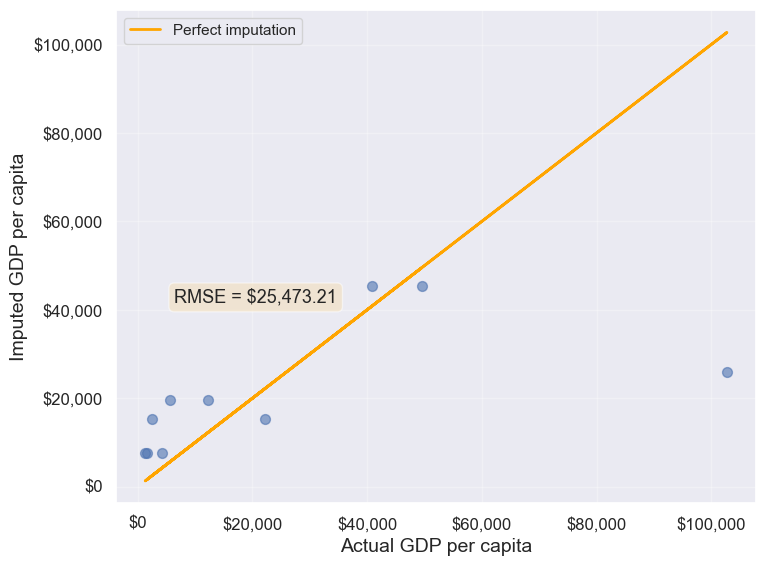

25473.20645170116

In [49]:
# Finding the mean GDP per capita of the continent
avg_gdpPerCapita = gdp_missing_data['gdpPerCapita'].groupby(gdp_missing_data['continent']).mean()

# Creating a copy of missing data to impute missing values
gdp_imputed_data = gdp_missing_data.copy()

# Replacing missing GDP per capita with the mean GDP per capita for the corresponding continent
for cont in avg_gdpPerCapita.index:
    gdp_imputed_data.loc[(gdp_imputed_data.continent==cont) & (gdp_imputed_data.gdpPerCapita.isnull()),
                     'gdpPerCapita'] = avg_gdpPerCapita[cont]

# Plot the actual vs predicted values
plot_actual_vs_predicted(gdp_imputed_data)

**Approach 2:** Using the `groupby()` and `transform()` methods.

The `transform()` function is a powerful tool for filling missing values in grouped data. It allows us to apply a function across each group and align the result back to the original DataFrame, making it perfect for filling missing values based on group statistics.

In this example, we use `transform()` to impute missing values in the `gdpPerCapita` column by filling them with the mean `gdpPerCapita` of each continent:


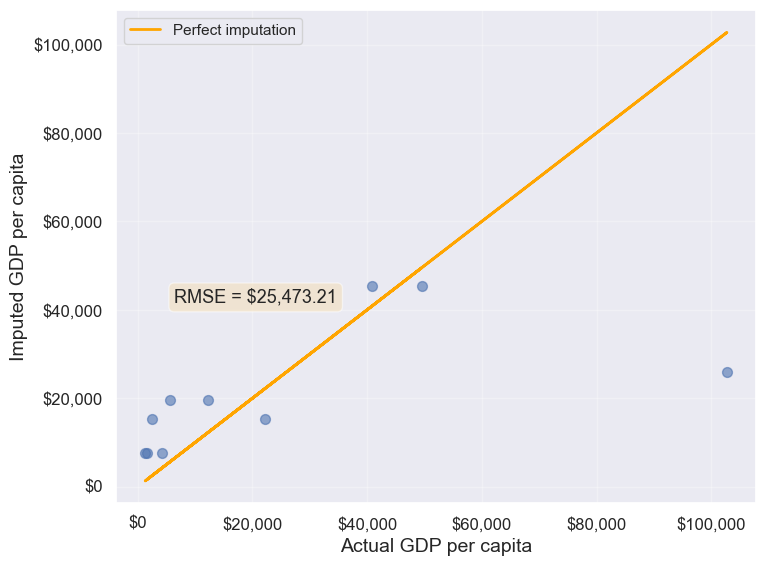

25473.20645170116

In [50]:
# Creating a copy of missing data to impute missing values
gdp_imputed_data = gdp_missing_data.copy()

# Grouping data by continent
grouped = gdp_missing_data.groupby('continent')

# Imputing missing values with the mean GDP per capita of the continent
gdp_imputed_data['gdpPerCapita'] = grouped['gdpPerCapita'].transform(lambda x: x.fillna(x.mean()))

# Plot the actual vs predicted values
plot_actual_vs_predicted(gdp_imputed_data)

Using the `transform()` function, missing values in gdpPerCapita for each group are filled with the group’s mean `gdpPerCapita`. This approach is not only more convenient to write but also faster compared to using for loops. While a for loop imputes missing values one group at a time, `transform()` performs built-in operations (like mean, sum, etc.) in a way that is optimized internally, making it more efficient.

Let's use `apply()` instead of `transform()` with `groupby()`

Please copy the code below and run it in your notebook:

```{python}
#Creating a copy of missing data to impute missing values
gdp_imputed_data = gdp_missing_data.copy()

#Grouping data by continent
grouped = gdp_missing_data.groupby('continent')

#Applying the lambda function on the 'gdpPerCapita' column of the groups
gdp_imputed_data['gdpPerCapita'] = grouped['gdpPerCapita'].apply(lambda x: x.fillna(x.mean()))

plot_actual_vs_predicted()
```

Why we ran into this error? and `apply()` doesn't work?

Here’s a deeper look at why `apply()` doesn’t work as expected here:

####  Behavior of `groupby().apply()` vs. `groupby().transform()`

- **`groupby().apply()`**: This method applies a function to each group and returns the result with a hierarchical (multi-level) index by default. This hierarchical index can make it difficult to align the result back to a single column in the original DataFrame.
  
- **`groupby().transform()`**: In contrast, `transform()` is specifically designed to apply a function to each group and return a Series that is aligned with the original DataFrame’s index. This alignment makes it directly compatible for assignment to a new or existing column in the original DataFrame.

####  Why `transform()` Works for Imputation

When using `transform()` to fill missing values, it applies the function (e.g., `fillna(x.mean())`) based on each group’s statistics, such as the mean, while keeping the result aligned with the original DataFrame’s index. This allows for smooth assignment to a column in the DataFrame without any index mismatch issues.

Additionally, `transform()` applies the function to each element in a group independently and returns a result that has the same shape as the original data, making it ideal for adding or modifying columns.


### Using [`filter()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.filter.html) on Groups

The `filter()` function filters entire groups based on a condition. It evaluates each group and keeps only those that meet the specified criteria.

Example: Keep only the countries where the mean life expectancy is greater than 70

In [51]:
# keep only the continent where the mean life expectancy is greater than 74
gdp_lifeExp_data.groupby('continent').filter(lambda x: x['lifeExp'].mean() > 74)['continent'].unique()

array(['Oceania'], dtype=object)

In [52]:
# keep only the country where the mean life expectancy is greater than 74
gdp_lifeExp_data.groupby('country').filter(lambda x: x['lifeExp'].mean() > 74)['country'].unique()

array(['Australia', 'Canada', 'Denmark', 'France', 'Iceland', 'Italy',
       'Japan', 'Netherlands', 'Norway', 'Spain', 'Sweden', 'Switzerland'],
      dtype=object)

Using `.nunique()` get the number of countries that satisfy this condition

In [53]:
gdp_lifeExp_data.groupby('country').filter(lambda x: x['lifeExp'].mean() > 74)['country'].nunique()

12

## Sampling data by group

If a dataset contains a large number of observations, operating on it can be computationally expensive. Instead, working on a sample of entire observations is a more efficient alterative.
The `groupby()` method combined with `apply()` can be used for stratified random sampling from a large dataset.

Before taking the random sample, let us find the number of countries in each continent.

In [54]:
gdp_lifeExp_data.continent.value_counts()

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64

Let us take a random sample of 650 observations from the entire dataset.

In [55]:
sample_lifeExp_data = gdp_lifeExp_data.sample(650)

Now, let us see the number of countries of each continent in our sample.

In [56]:
sample_lifeExp_data.continent.value_counts()

continent
Africa      236
Asia        154
Europe      136
Americas    113
Oceania      11
Name: count, dtype: int64

Some of the continent have a very low representation in the data. To rectify this, we can take a random sample of 130 observations from each of the 5 continents. In other words, we can take a random sample from each of the continent-based groups.

In [57]:
evenly_sampled_lifeExp_data = gdp_lifeExp_data.groupby('continent').apply(lambda x:x.sample(130, replace=True), include_groups=False)

group_sizes = evenly_sampled_lifeExp_data.groupby(level=0).size()
print(group_sizes)

continent
Africa      130
Americas    130
Asia        130
Europe      130
Oceania     130
dtype: int64


The above stratified random sample equally represents all the continent.

## [`corr()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.DataFrameGroupBy.corr.html): Correlation by group

The [`corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) method of the *GroupBy* object returns the correlation between all pairs of columns within each group.

**Example:** Find the correlation between `lifeExp` and `gdpPercap` for each continent-country level combination.

In [58]:
gdp_lifeExp_data.groupby(['continent','country']).apply(lambda x:x['lifeExp'].corr(x['gdpPercap']), include_groups=False)

continent  country       
Africa     Algeria           0.904471
           Angola           -0.301079
           Benin             0.843949
           Botswana          0.005597
           Burkina Faso      0.881677
                               ...   
Europe     Switzerland       0.980715
           Turkey            0.954455
           United Kingdom    0.989893
Oceania    Australia         0.986446
           New Zealand       0.974493
Length: 142, dtype: float64

Life expectancy is closely associated with GDP per capita across most continent-country combinations.

## Independent Study

### Practice exercise 1

Read the spotify dataset from `spotify_data.csv` that contains information about tracks and artists

####
Find the mean and standard deviation of the track popularity for each genre.

####
Create a new categorical column, `energy_lvl`, with two levels – 'Low energy' and 'High energy' – using equal-sized bins based on the track’s energy level. Then, calculate the mean, standard deviation, and 90th percentile of track popularity for each genre and energy level combination

####
Find the mean and standard deviation of track popularity and danceability for each genre and energy level. What insights you can gain from the generated table

####
For each genre and energy level, find the mean and standard deviation of the track popularity, and the minimum and maximum values of loudness.

####
Find the most popular artist from each genre.

####
Filter the first 4 columns of the spotify dataset. Drop duplicate observartions in the resulting dataset using the Pandas DataFrame method [`drop_duplicates()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html). Find the top 3 most popular artists for each genre.

####
The spotify dataset has more than 200k observations. It may be expensive to operate with so many observations. Take a random sample of 650 observations to analyze spotify data, such that all genres are equally represented.

####
Find the correlation between `danceability` and `track popularity` for each genre-energy level combination.


####
Find the number of observations in each group, where each groups corresponds to a distinct genre-energy lvl combination

####
Find the percentage of observations in each group of the above table.

####
What percentage of unique tracks are contributed by the top 5 artists of each genre?

**Hint:** Find the top 5 artists based on `artist_popularity` for each genre. Count the total number of unique tracks (`track_name`) contributed by these artists. Divide this number by the total number of unique tracks in the data. The `nunique()` function will be useful.